# Tutorial: lattice Boltzmann simulation of a squirmer in a channel

This notebook walks through `lbm-squirmer` step by step. By the end you will know how to

1. build and run the solver,
2. validate the fluid solver against an exact Navier–Stokes solution (duct flow),
3. understand the squirmer model (pushers, pullers, neutral swimmers),
4. check the simulated squirmer against Blake's analytic flow field,
5. simulate and analyse squirmer trajectories between two walls.

**Prerequisites:** a C++17 compiler, Python with `numpy`, `scipy`, `matplotlib`.
Everything is in *lattice units* (grid spacing = time step = 1, fluid density = 1).
Equations and implementation details are also collected in the `README.md`.

> **Run time.** Every simulation executed here takes seconds to about a minute on one core. Long
> trajectories (10–20 minutes each) are loaded from `examples/reference_data/`; set `RUN_LONG = True`
> below to recompute them yourself.

## 0. Setup

In [1]:
import sys, os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":          # notebook opened from notebooks/
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "postprocessing"))
import lbm_post as lp

OUT = ROOT / "outputs" / "tutorial"   # all results of this notebook go here
OUT.mkdir(parents=True, exist_ok=True)
RUN_LONG = False                      # True: recompute the long channel trajectories (~35 min)

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
lp.build(quiet=False)                 # runs `make`
print("solver:", lp.BINARY)

make: Entering directory '/home/claude/lbm-squirmer'
make: Nothing to be done for 'all'.
make: Leaving directory '/home/claude/lbm-squirmer'
solver: /home/claude/lbm-squirmer/bin/lbm_squirmer


The solver is a single executable driven by an **input file** of `key = value` lines. Any key can be
overridden on the command line (`key=value`). From Python, `lp.run(input_file, overrides, output_dir)` does
exactly that and returns the console output.

## 1. The lattice Boltzmann method in a nutshell

Instead of solving the Navier–Stokes equations directly, LBM evolves particle distributions
$f_i(\mathbf x,t)$ that move along a small set of discrete velocities $\mathbf c_i$:

$$f_i(\mathbf x + \mathbf c_i, t+1) = f_i(\mathbf x,t) + \Omega_i + S_i \qquad\text{(collide, then stream)}.$$

Density and velocity are moments, $\rho = \sum_i f_i$ and $\rho\mathbf u = \sum_i f_i \mathbf c_i + \mathbf F/2$.
We use the **D3Q19** lattice: 1 rest velocity, 6 to the faces and 12 to the edges of a cube.

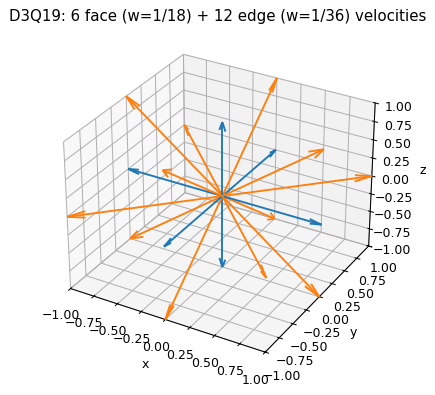

sum w_i           = 1.0
sum w_i c_ia c_ib =
 [[0.33333333 0.         0.        ]
 [0.         0.33333333 0.        ]
 [0.         0.         0.33333333]]  -> c_s^2 = 1/3 on the diagonal


In [2]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
cx = np.array([0, 1,-1, 0, 0, 0, 0, 1,-1, 1,-1, 1,-1, 1,-1, 0, 0, 0, 0])
cy = np.array([0, 0, 0, 1,-1, 0, 0, 1,-1,-1, 1, 0, 0, 0, 0, 1,-1, 1,-1])
cz = np.array([0, 0, 0, 0, 0, 1,-1, 0, 0, 0, 0, 1,-1,-1, 1, 1,-1,-1, 1])
w  = np.array([1/3] + [1/18]*6 + [1/36]*12)

fig = plt.figure(figsize=(5, 5)); ax = fig.add_subplot(projection="3d")
for i in range(1, 19):
    ax.quiver(0, 0, 0, cx[i], cy[i], cz[i], color="C0" if i <= 6 else "C1", arrow_length_ratio=0.12)
ax.set(xlim=(-1,1), ylim=(-1,1), zlim=(-1,1), xlabel="x", ylabel="y", zlabel="z",
       title="D3Q19: 6 face (w=1/18) + 12 edge (w=1/36) velocities")
plt.show()

# The weights make the lattice isotropic up to the order needed for Navier-Stokes:
c = np.stack([cx, cy, cz], axis=1)
print("sum w_i           =", w.sum())
print("sum w_i c_ia c_ib =\n", np.einsum("i,ia,ib->ab", w, c, c), " -> c_s^2 = 1/3 on the diagonal")

**Collision (TRT).** Each population is split into parts that are symmetric and antisymmetric under
$\mathbf c_i \to -\mathbf c_i$; each part relaxes towards equilibrium at its own rate:

$$\Omega_i = -\omega^+ (f_i^+ - f_i^{eq,+}) - \omega^- (f_i^- - f_i^{eq,-}), \qquad
\nu = \frac{1}{3}\Big(\frac{1}{\omega^+} - \frac12\Big),\qquad
\Lambda = \Big(\frac{1}{\omega^+}-\frac12\Big)\Big(\frac{1}{\omega^-}-\frac12\Big) = \frac{3}{16}.$$

The choice $\Lambda = 3/16$ puts the no-slip wall exactly half-way between the last fluid node and the
first wall node, whatever the viscosity.

**Walls (halfway bounce-back).** A population that would enter a wall node is reflected back where it came from:
$f_{\bar i}(\mathbf x, t+1) = f_i^*(\mathbf x, t)$. With fluid nodes $y = 1, \dots, N_y-2$ the walls sit at $y = 0.5$
and $y = N_y - 1.5$, so the channel width is $H = N_y - 2$.

## 2. Step 1 — Validate the fluid solver: flow in a square duct

A constant body force $G$ along $x$ (equivalent to a pressure gradient) drives flow through a square duct
with walls in $y$ and $z$. The exact solution is a Fourier series (see README §6.1). Here is the input file:

In [3]:
print((ROOT / "inputs" / "duct.in").read_text())

# ---------------------------------------------------------------------------
# Pressure-driven flow in a square duct (walls in y and z), no squirmer.
# Validates the fluid solver against the exact series solution.
# Channel width H = ny - 2 = 32, force density fx drives the flow along x.
# x is periodic and the flow is x-invariant, so a short domain (nx = 4) suffices.
# ---------------------------------------------------------------------------
nx = 4
ny = 34
nz = 34
tau = 0.8
fx = 5e-5
walls_y = 1
walls_z = 1
squirmer = 0
steps = 100000
tol = 1e-12            # stop at steady state
print_every = 1000
output_dir = outputs
prefix = duct



The flow does not depend on $x$, so a periodic domain only 4 nodes long is enough. We stop at steady state (`tol`).

In [4]:
log = lp.run(ROOT / "inputs" / "duct.in", {"prefix": "duct"}, output_dir=OUT)
print("\n".join(log.splitlines()[-4:]))

t=   16000  u_max=3.764989e-02  F_wall_x=2.048000e-01  rel.change=3.096e-13
16000 steps in 10.1 s (7.30 MLUPS)
relative L2 error vs exact Poiseuille solution: 2.1053e-04
output written to /home/claude/lbm-squirmer/outputs/tutorial/duct_*


The output directory now contains `duct_final.vtk` (the full 3D field; open it in ParaView), centre-line
profiles, and a machine-readable `duct_summary.txt`. We read the field with `lp.read_vtk`: every array is indexed
`[z, y, x]` (vectors `[z, y, x, component]`).

In [5]:
vtk = lp.read_vtk(OUT / "duct_final.vtk")
print("dims (nx, ny, nz):", vtk["dims"], "  fields:", [k for k in vtk if k != "dims"])
summary = lp.read_keyvalue(OUT / "duct_summary.txt")
print(f"relative L2 error: {summary['l2_error']:.2e}")
print(f"force on walls   : {summary['wall_force'][0]:.6f}")
print(f"total body force : {summary['body_force_total'][0]:.6f}   (momentum balance)")

dims (nx, ny, nz): (4, 34, 34)   fields: ['flag', 'density', 'velocity']
relative L2 error: 2.11e-04
force on walls   : 0.204800
total body force : 0.204800   (momentum balance)


**Grid convergence.** We repeat the run for channel widths $H = 8, 16, 32$ and scale the force as $1/H^2$, so the
maximum velocity (and therefore the Reynolds and Mach numbers) stays the same. A second-order method should reduce
the error 4× per doubling.

H =   8   L2 error = 4.025e-03
H =  16   L2 error = 8.803e-04
H =  32   L2 error = 2.105e-04
observed order: [2.19 2.06]


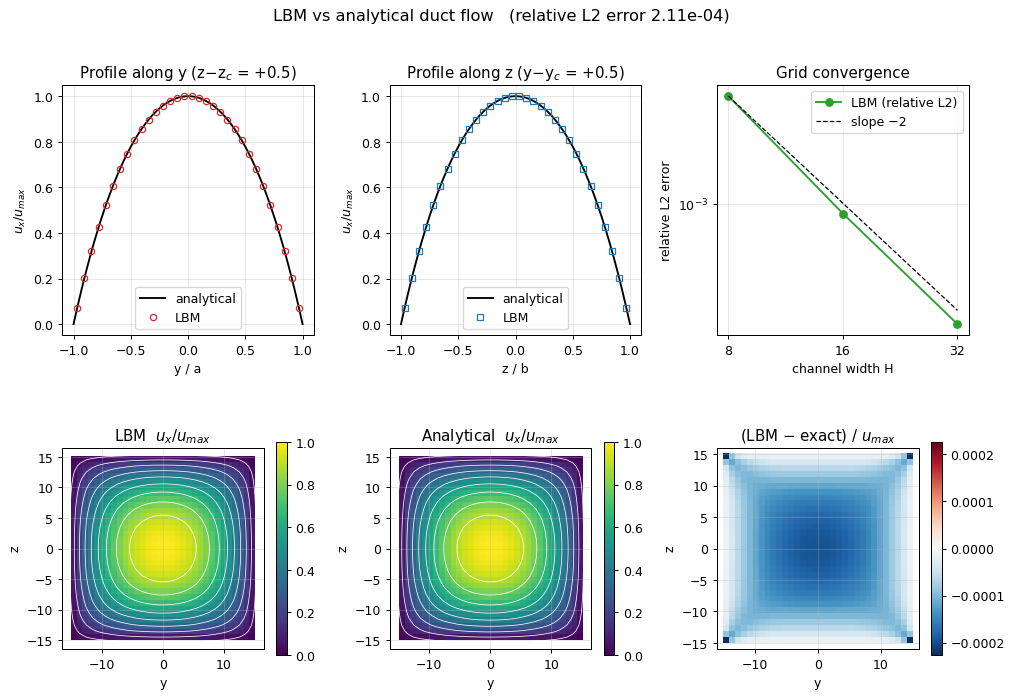

In [6]:
widths, errors = [8, 16, 32], []
tau = 0.8; nu = (tau - 0.5) / 3
for H in widths:
    fx = 5e-5 * (32 / H) ** 2
    lp.run(ROOT / "inputs" / "duct.in", dict(nx=4, ny=H + 2, nz=H + 2, tau=tau, fx=fx, prefix=f"duct_H{H}"), output_dir=OUT)
    errors.append(lp.read_keyvalue(OUT / f"duct_H{H}_summary.txt")["l2_error"])
for H, e in zip(widths, errors):
    print(f"H = {H:3d}   L2 error = {e:.3e}")
print("observed order:", np.round(np.log2(np.array(errors[:-1]) / np.array(errors[1:])), 2))

vtk32 = lp.read_vtk(OUT / "duct_H32_final.vtk")
fig, err = lp.plot_duct_validation(vtk32, 5e-5, nu, convergence=(widths, errors))
plt.show()

The simulated profiles lie on the exact curves, the error is below $10^{-3}$ and decreases at second order.

> **Try it:** run with `walls_z=0 nz=1` (walls in $y$ only). This is plane Poiseuille flow, which TRT with
> $\Lambda = 3/16$ reproduces to round-off.

## 3. Step 2 — The squirmer model

A squirmer is a rigid sphere (radius $R$, orientation $\mathbf e$) that moves by imposing a tangential *slip
velocity* on the fluid at its surface. With $\cos\theta = \mathbf e\cdot\hat{\mathbf r}$:

$$\mathbf u_s = B_1 (1 + \beta\cos\theta)\,(\cos\theta\,\hat{\mathbf r} - \mathbf e),\qquad \beta = B_2/B_1 .$$

* $B_1$ sets the speed: in free space $U_0 = \tfrac23 B_1$.
* $\beta$ sets the *type*: $\beta<0$ **pusher** (thrust from behind, e.g. bacteria), $\beta=0$ **neutral**,
  $\beta>0$ **puller** (thrust from the front, e.g. *Chlamydomonas*).

The slip profile shows where on the surface the swimmer pushes fluid backwards:

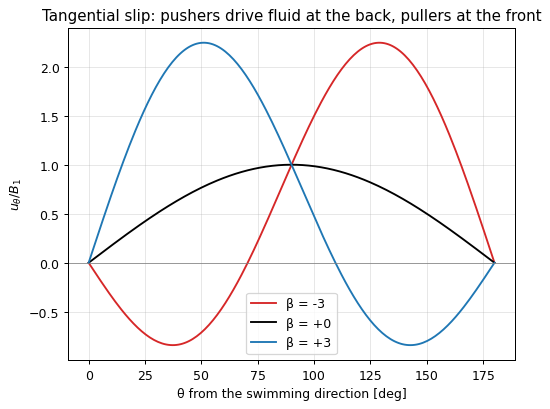

In [7]:
theta = np.linspace(0, np.pi, 200)
for beta, col in [(-3, "C3"), (0, "k"), (3, "C0")]:
    plt.plot(np.degrees(theta), np.sin(theta) * (1 + beta * np.cos(theta)), c=col, label=f"β = {beta:+d}")
plt.axhline(0, c="0.5", lw=0.6)
plt.xlabel("θ from the swimming direction [deg]"); plt.ylabel(r"$u_\theta / B_1$")
plt.title("Tangential slip: pushers drive fluid at the back, pullers at the front"); plt.legend(); plt.show()

In unbounded Stokes flow the flow around a squirmer is known exactly (Blake 1971); `lp.blake_velocity` implements it.
The $\beta$ term is a **force dipole** (stresslet) that decays as $1/r^2$. It dominates how swimmers interact with walls.

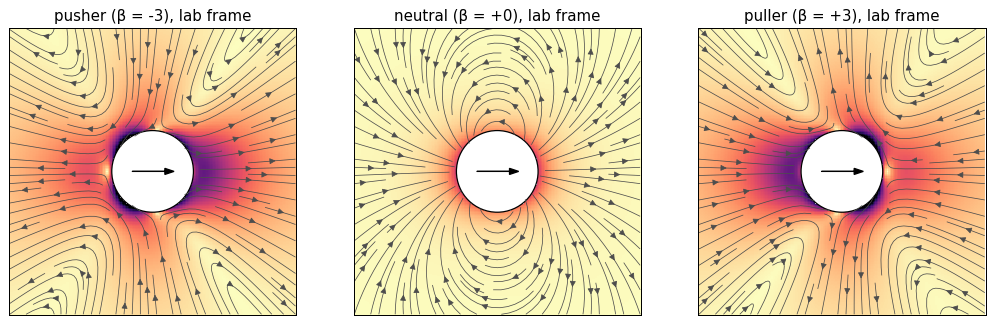

In [8]:
R, B1 = 4.0, 0.015; U0 = 2 * B1 / 3
g = np.linspace(-14, 14, 201); GX, GY = np.meshgrid(g, g)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
for ax, beta, name in zip(axes, [-3, 0, 3], ["pusher", "neutral", "puller"]):
    u = lp.blake_velocity(GX, GY, 0 * GX, R, B1, beta)
    ax.pcolormesh(GX, GY, np.hypot(u[0], u[1]) / U0, cmap="magma_r", vmin=0, vmax=2.2, shading="auto")
    ax.streamplot(g, g, np.nan_to_num(u[0]), np.nan_to_num(u[1]), color="0.3", density=1.2, linewidth=0.6)
    ax.add_patch(plt.Circle((0, 0), R, fc="w", ec="k")); ax.arrow(-2, 0, 3.2, 0, head_width=0.6, color="k")
    ax.set(aspect="equal", title=f"{name} (β = {beta:+d}), lab frame", xticks=[], yticks=[]); ax.grid(False)
plt.show()

### How the squirmer lives on the lattice

* Nodes inside the sphere are flagged as solid. Populations hitting the sphere are bounced back with a correction
  that transfers the local surface velocity $\mathbf u_b = \mathbf U + \boldsymbol\Omega\times\mathbf r_b + \mathbf u_s$:
  $\;f_{\bar i} = f_i^* - 6 w_i\rho\,\mathbf c_i\cdot\mathbf u_b$.
* The momentum exchanged on those links gives the hydrodynamic force and torque on the sphere.
* Newton–Euler equations then move and rotate the sphere; nodes it covers or uncovers exchange momentum with it.

## 4. Step 3 — Validate the squirmer in a periodic box

We release a squirmer in a fully periodic box (no walls), once for each type, and compare its speed and flow field
with the analytic solution.

In [9]:
print((ROOT / "inputs" / "bulk_squirmer.in").read_text())

# ---------------------------------------------------------------------------
# Single squirmer in a fully periodic box (no walls): swimming speed and
# flow field are compared with the unbounded Blake solution.
# ---------------------------------------------------------------------------
nx = 48
ny = 48
nz = 48
tau = 1.0
walls_y = 0
walls_z = 0
squirmer = 1
radius = 4
b1 = 0.015             # U0 = 2 B1 / 3 = 0.01
beta = 0               # -3 pusher, 0 neutral, +3 puller
angle = 0
planar = 1
steps = 3000
print_every = 500
traj_every = 10
output_dir = outputs
prefix = bulk



In [10]:
cases = []
for beta, label in [(-3, "pusher β = −3"), (0, "neutral β = 0"), (3, "puller β = +3")]:
    prefix = f"bulk_beta{beta:+d}"
    lp.run(ROOT / "inputs" / "bulk_squirmer.in",
           dict(nx=40, ny=40, nz=40, beta=beta, steps=2000, prefix=prefix), output_dir=OUT)
    traj = lp.read_traj(OUT / f"{prefix}_traj.dat")
    speed = traj["Ux"][traj["t"] > 1000].mean() / U0
    print(f"{label:16s}  <U>/U0 = {speed:.3f}   max|Uy| = {abs(traj['Uy']).max():.1e}   max|angle| = {abs(traj['angle']).max():.1e} deg")
    cases.append(dict(beta=beta, label=label, vtk=lp.read_vtk(OUT / f"{prefix}_final.vtk"),
                      state=lp.read_keyvalue(OUT / f"{prefix}_squirmer.dat")))

pusher β = −3     <U>/U0 = 1.143   max|Uy| = 3.9e-17   max|angle| = 0.0e+00 deg


neutral β = 0     <U>/U0 = 0.985   max|Uy| = 4.0e-17   max|angle| = 0.0e+00 deg


puller β = +3     <U>/U0 = 0.865   max|Uy| = 3.7e-17   max|angle| = 0.0e+00 deg


* The neutral squirmer swims at $\approx U_0$ in a straight line without rotating.
* The pusher is faster and the puller slower. This is a real effect of the small but finite Reynolds number
  ($Re = 2RU_0/\nu \approx 0.5$), not an error.

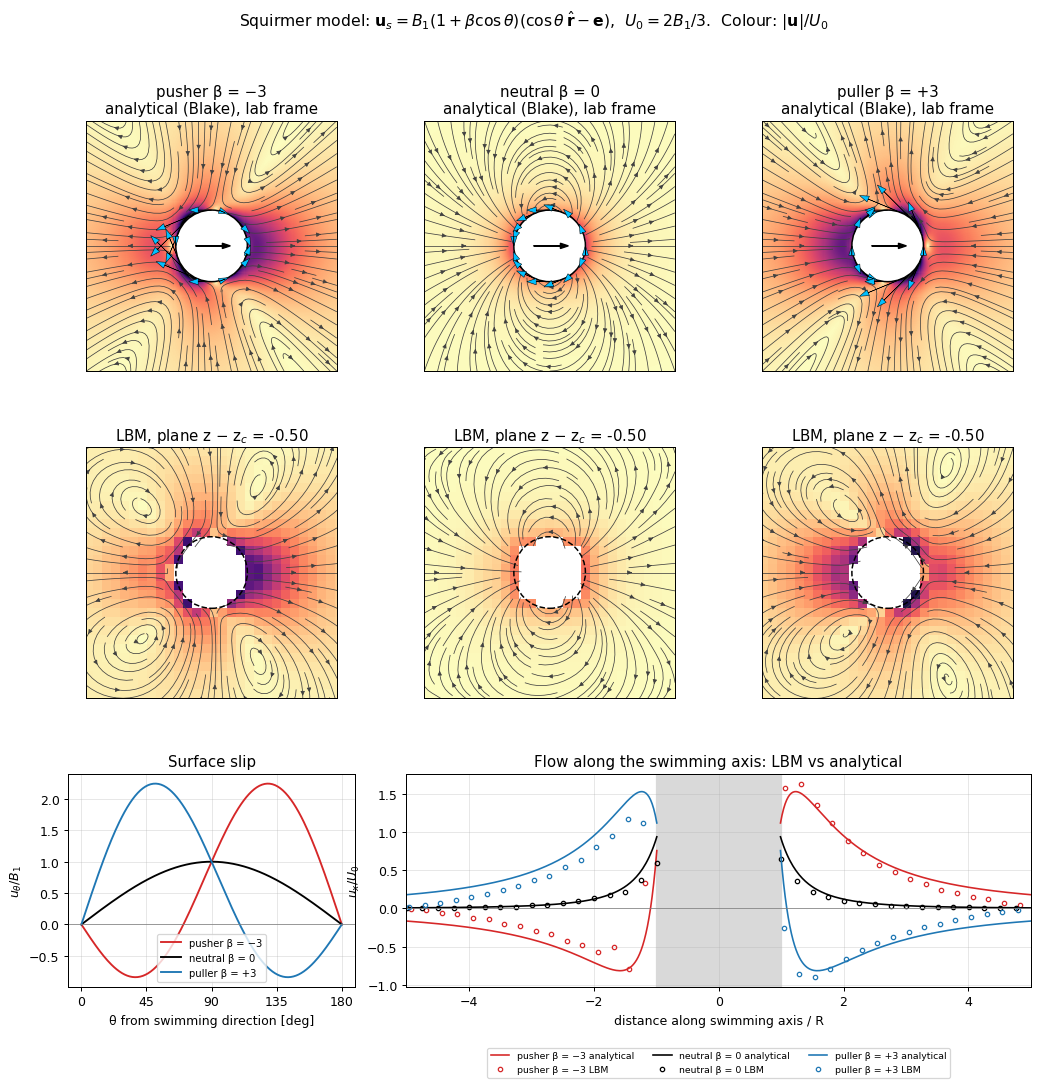

pusher β = −3    near-field relative difference vs Blake: 0.21
neutral β = 0    near-field relative difference vs Blake: 0.16
puller β = +3    near-field relative difference vs Blake: 0.22


In [11]:
fig, errs = lp.plot_squirmer_model(cases, R, B1)
plt.show()
for k, v in errs.items():
    print(f"{k:16s} near-field relative difference vs Blake: {v['near_field']:.2f}")

The LBM reproduces the characteristic flow of each swimmer type. The remaining 15–25 % difference close to the sphere
comes from the coarse sphere ($R = 4$ lattice units), the periodic images of the swimmer, and $Re > 0$ (Blake's
solution is for $Re = 0$).

## 5. Step 4 — Squirmer in a slit channel

Now the swimmer moves between two no-slip walls at $y = 0.5$ and $y = N_y - 1.5$; $x$ and $z$ are periodic.

| parameter | value |
|---|---|
| channel width | $H = 32$ |
| radius | $R = 4$ → confinement $2R/H = 0.25$ |
| Reynolds number | $Re = 2RU_0/\nu = 0.48$ |
| start | on the centreline, $30°$ from the $x$-axis (must be $< 45°$) |
| motion | restricted to the $x$–$y$ plane (`planar = 1`) |

**Soft wall potential.** Within about one lattice spacing of a wall, the lubrication flow in the gap is not resolved.
A weak, smooth repulsion keeps the swimmer off the wall:

$$F_w(h) = \varepsilon F_S \Big(1 - \frac{h}{h_c}\Big)^2 \quad (h < h_c),\qquad F_S = 6\pi\mu R U_0,$$

where $h$ is the surface-to-wall gap. With $\varepsilon = 0.2$ the force never exceeds 20 % of the Stokes drag.
A hard minimum gap $h_{min} = 0.5$ acts as a last resort.

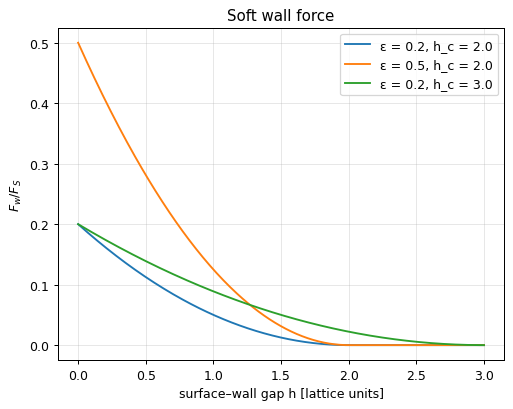

In [12]:
h = np.linspace(0, 3, 300)
for eps, hc in [(0.2, 2.0), (0.5, 2.0), (0.2, 3.0)]:
    plt.plot(h, eps * np.clip(1 - h / hc, 0, None) ** 2, label=f"ε = {eps}, h_c = {hc}")
plt.xlabel("surface–wall gap h [lattice units]"); plt.ylabel(r"$F_w / F_S$")
plt.title("Soft wall force"); plt.legend(); plt.show()

### A short live run

We simulate the first 6000 steps (about 2 channel-crossing times $H/U_0$) of the neutral squirmer.

In [13]:
print((ROOT / "inputs" / "channel_neutral.in").read_text())
log = lp.run(ROOT / "inputs" / "channel_neutral.in",
             dict(steps=6000, print_every=1000, prefix="channel_short"), output_dir=OUT)
print("\n".join(log.splitlines()[-9:]))

# ---------------------------------------------------------------------------
# Neutral squirmer in a slit channel: walls in y, periodic in x and z.
# H = ny - 2 = 32, R = 4 (2R/H = 0.25), Re = 2 R U0 / nu = 0.48.
# Starts on the centreline, 30 degrees from the x-axis (|angle| < 45 required).
# Expected: sustained wall-to-wall oscillation (period ~ 7.4 H/U0).
# ---------------------------------------------------------------------------
nx = 64
ny = 34
nz = 32
tau = 1.0
walls_y = 1
walls_z = 0
squirmer = 1
radius = 4
b1 = 0.015
beta = 0
angle = 30
planar = 1             # keep the motion in the x-y plane
eps = 0.2              # soft wall potential, max force = eps * 6 pi mu R U0
hc = 2.0               # potential range (lattice units)
hmin = 0.5             # hard safety gap
steps = 60000
print_every = 2000
traj_every = 50
output_dir = outputs
prefix = channel_neutral



t=    1000  X=(    39.75,  21.25,  15.50)  angle=  29.88 deg  |U|/U0=0.962  <rho>=0.999999
t=    2000  X=(    48.17,  25.85,  15.50)  angle=  28.66 deg  |U|/U0=0.940  <rho>=1.000001
t=    3000  X=(    56.54,  28.00,  15.50)  angle=  12.80 deg  |U|/U0=0.855  <rho>=1.000001
t=    4000  X=(    65.44,  26.84,  15.50)  angle=  -6.90 deg  |U|/U0=0.923  <rho>=1.000000
t=    5000  X=(    74.77,  25.36,  15.50)  angle= -11.97 deg  |U|/U0=0.967  <rho>=1.000000
t=    6000  X=(    84.17,  23.26,  15.50)  angle= -13.75 deg  |U|/U0=0.966  <rho>=1.000002
6000 steps in 65.7 s (6.36 MLUPS)
hard-gap safety activations: 745 steps
output written to /home/claude/lbm-squirmer/outputs/tutorial/channel_short_*


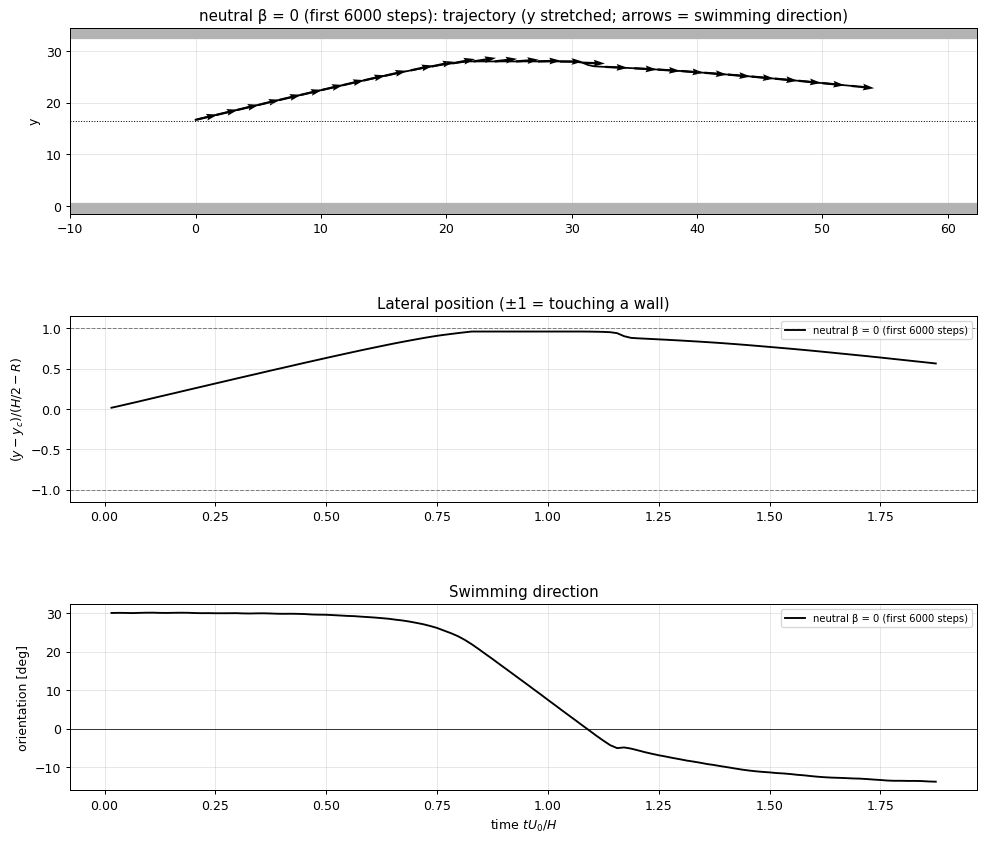

In [14]:
short = lp.read_traj(OUT / "channel_short_traj.dat")
lp.plot_trajectories([(short, "neutral β = 0 (first 6000 steps)", "k")], ny=34, R=R, U0=U0)
plt.show()

The swimmer heads for the upper wall, is turned by its hydrodynamic interaction with the wall, and swims away.

Let's also look at the flow field it generates next to the wall, in the plane $z = z_c$:

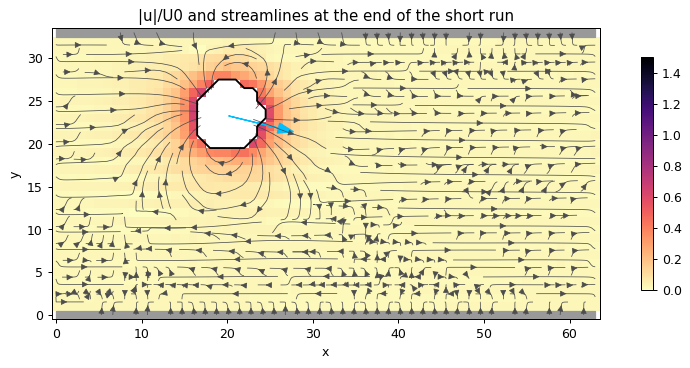

In [15]:
vtk = lp.read_vtk(OUT / "channel_short_final.vtk")
st = lp.read_keyvalue(OUT / "channel_short_squirmer.dat")
nx, ny, nz = vtk["dims"]
zc = int(round(st["X"][2] - 0.5))
ux, uy = vtk["velocity"][zc, :, :, 0], vtk["velocity"][zc, :, :, 1]
fl = vtk["flag"][zc]
xs, ys = np.arange(nx), np.arange(ny)
fig, ax = plt.subplots(figsize=(12, 4.2))
speed = np.where(fl == 0, np.hypot(ux, uy) / U0, np.nan)
pc = ax.pcolormesh(xs, ys, speed, cmap="magma_r", vmin=0, vmax=1.5, shading="nearest")
ax.streamplot(xs, ys, np.where(fl == 0, ux, 0), np.where(fl == 0, uy, 0), color="0.3", density=1.6, linewidth=0.6)
ax.contour(xs, ys, (fl == 2).astype(float), levels=[0.5], colors="k")
ax.fill_between(xs, -0.5, 0.5, color="0.6"); ax.fill_between(xs, ny - 1.5, ny - 0.5, color="0.6")
e = st["e"]; X = st["X"]
ax.arrow(X[0] % nx, X[1], 6 * e[0], 6 * e[1], head_width=1.2, color="deepskyblue")
ax.set(aspect="equal", xlabel="x", ylabel="y", title="|u|/U0 and streamlines at the end of the short run"); ax.grid(False)
fig.colorbar(pc, ax=ax, shrink=0.8); plt.show()

### Long-time trajectories: neutral, puller, pusher

The characteristic behaviour takes 30–90 thousand steps to develop. Unless `RUN_LONG = True`, we load reference
trajectories produced with exactly the provided input files (`examples/reference_data/README.md` lists the commands).

neutral : 800 samples up to t = 40000
puller  : 1800 samples up to t = 90000
pusher  : 600 samples up to t = 30000


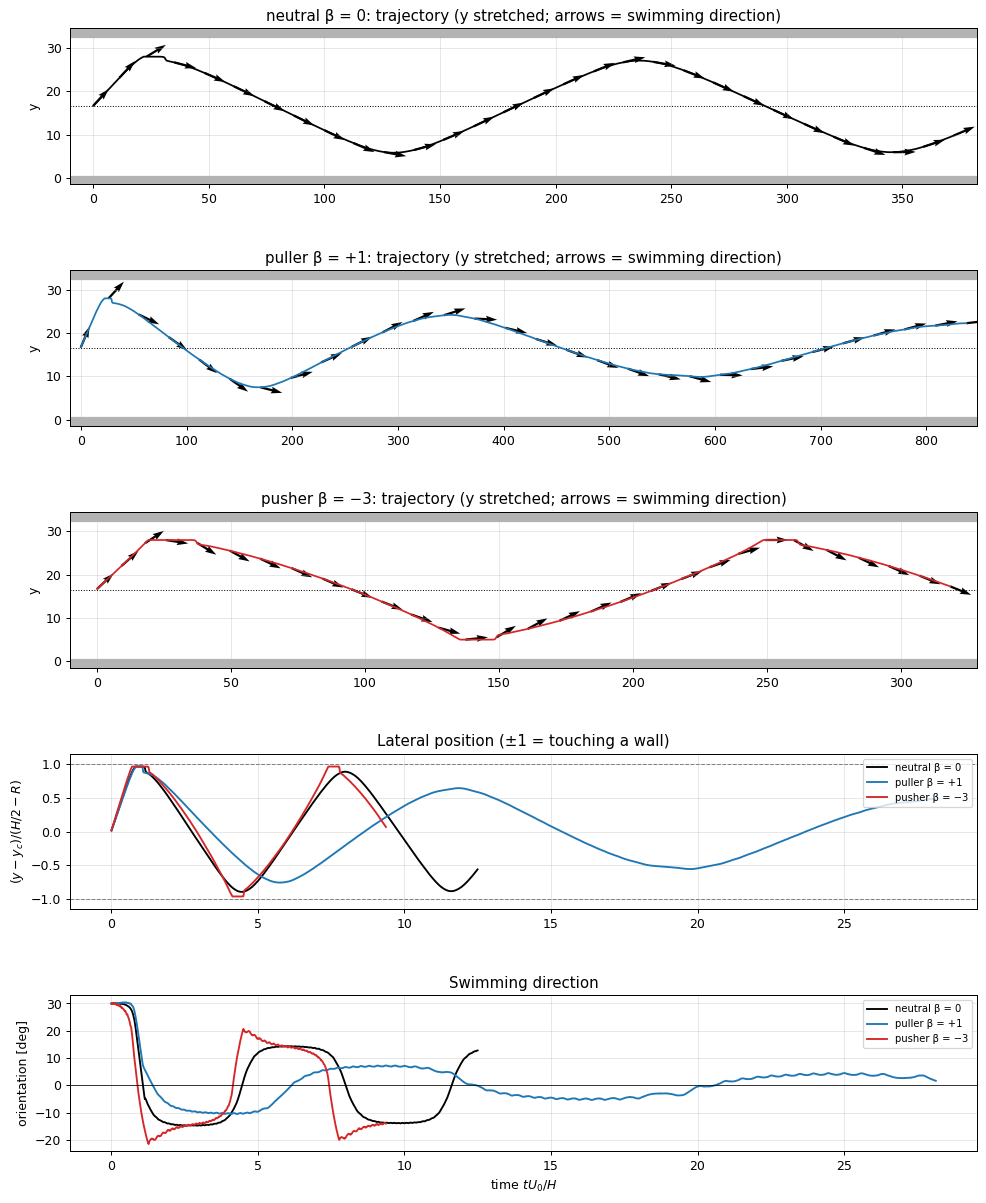

In [16]:
REF = ROOT / "examples" / "reference_data"
runs = {"neutral": ("channel_neutral.in", 40000), "puller": ("channel_puller.in", 90000), "pusher": ("channel_pusher.in", 30000)}
traj = {}
for name, (inp, steps) in runs.items():
    if RUN_LONG:
        lp.run(ROOT / "inputs" / inp, dict(steps=steps, prefix=f"channel_{name}"), output_dir=OUT)
        traj[name] = lp.read_traj(OUT / f"channel_{name}_traj.dat")
    else:
        traj[name] = lp.read_traj(REF / f"channel_{name}_traj.dat")
    print(f"{name:8s}: {len(traj[name]['t'])} samples up to t = {int(traj[name]['t'][-1])}")

lp.plot_trajectories([(traj["neutral"], "neutral β = 0", "k"),
                      (traj["puller"], "puller β = +1", "C0"),
                      (traj["pusher"], "pusher β = −3", "C3")], ny=34, R=R, U0=U0)
plt.show()

### Quantifying the motion

`lp.oscillation_extrema` returns the time $T = tU_0/H$, the normalised lateral position
$y_n = (y - y_c)/(H/2 - R)$ ($\pm1$ = touching a wall) and the indices of its turning points.

neutral : turning points yn = [-0.891  0.882 -0.88 ]
          period ≈ 7.16 H/U0 (constant amplitude -> limit cycle)
puller  : turning points |yn| = [0.753 0.64  0.554]
          decay rate ≈ 0.022 U0/H  (e-folding time ≈ 46 H/U0)


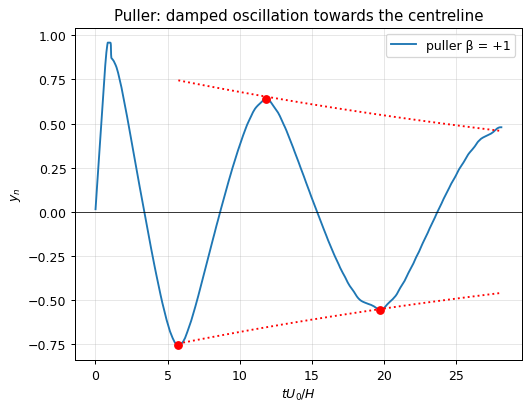

pusher  : fraction of time at the hard gap (h <= 0.5): 13.2%


In [17]:
# neutral: period and amplitude of the sustained oscillation
T, yn, idx = lp.oscillation_extrema(traj["neutral"], ny=34, R=R, U0=U0, t_skip=1.5, prominence=0.3)
print("neutral : turning points yn =", np.round(yn[idx], 3))
print(f"          period ≈ {2 * np.diff(T[idx]).mean():.2f} H/U0 (constant amplitude -> limit cycle)")

# puller: damped oscillation -> fit an exponential envelope
T, yn, idx = lp.oscillation_extrema(traj["puller"], ny=34, R=R, U0=U0, t_skip=1.5, prominence=0.01)
amp = np.abs(yn[idx])
k, lnA = np.polyfit(T[idx], np.log(amp), 1)
print("puller  : turning points |yn| =", np.round(amp, 3))
print(f"          decay rate ≈ {-k:.3f} U0/H  (e-folding time ≈ {-1/k:.0f} H/U0)")

plt.plot(T, yn, c="C0", label="puller β = +1")
tt = np.linspace(T[idx][0], T[-1], 100)
plt.plot(tt, np.exp(lnA + k * tt), "r:", tt, -np.exp(lnA + k * tt), "r:")
plt.plot(T[idx], yn[idx], "ro"); plt.axhline(0, c="k", lw=0.6)
plt.xlabel(r"$tU_0/H$"); plt.ylabel(r"$y_n$"); plt.title("Puller: damped oscillation towards the centreline"); plt.legend(); plt.show()

# pusher: how much did it rely on the hard gap?
gap = np.minimum(traj["pusher"]["Y"] - R - 0.5, (34 - 1.5) - traj["pusher"]["Y"] - R)
print(f"pusher  : fraction of time at the hard gap (h <= 0.5): {(gap <= 0.501).mean():.1%}")

**Interpretation**

* **Neutral squirmer:** a sustained wall-to-wall oscillation (a limit cycle), independent of the initial angle.
* **Puller:** it escapes the wall after the first contact, and each crossing is smaller than the last. The swimmer
  slowly converges to sliding along the centreline, with an e-folding time of a few tens of $H/U_0$.
* **Pusher:** its stresslet draws it towards the walls. Here it spends a sizeable fraction of the time pressed against
  the hard gap, so its detailed near-wall behaviour depends on the wall model (`eps`, `hc`, `hmin`) and the sphere
  resolution. Check such results with a larger $R$.

## 6. Exercises and next steps

1. **β scan.** Run `inputs/channel_puller.in` with `beta=0.5, 2, 3` and compare the decay rates. How does the
   damping depend on β?
2. **Initial angle.** Repeat the neutral run with `angle=10` and `angle=40`. Is the oscillation amplitude the same?
3. **Wall model.** Rerun the pusher with `eps=1.0` or `hc=3`. Does it still touch the hard gap?
4. **Background flow.** Add a pressure-driven flow with `fx=1e-6` (Poiseuille flow plus swimming). What happens to
   upstream versus downstream swimmers?
5. **3D motion.** Set `planar=0` and watch the $z$ coordinate of the trajectory.
6. **Resolution.** Double everything (`radius=8 ny=66 nz=64 nx=128`) to check that the results are converged.

The flow fields (`*.vtk`) can be opened in ParaView to make 3D visualisations and animations (use `vtk_every=...`).